# Fit the narrow lines of SDSS J092537.83+640921.7
* Remove the stellar component
* Determine the refined redshift
* Create the narrow line template

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from scipy.ndimage import gaussian_filter1d
from copy import deepcopy

from astropy.modeling import models, fitting
import sys
sys.path.append('/Users/shangguan/Softwares/my_modules/SAGAN/')
import galspec
from extinction import ccm89, remove
import spectres

import temp_utils as tu

import matplotlib as mpl
mpl.rc("xtick", direction="in", labelsize=16)
mpl.rc("ytick", direction="in", labelsize=16)
mpl.rc("xtick.major", width=1., size=8)
mpl.rc("ytick.major", width=1., size=8)
mpl.rc("xtick.minor", width=1., size=5)
mpl.rc("ytick.minor", width=1., size=5)

# automatic reload the modules
%load_ext autoreload
%autoreload 2

ls_km = 2.99792e5 # km/s
wave_dict = galspec.utils.line_wave_dict
label_dict = galspec.utils.line_label_dict

label_bHa = tu.line_label_map['bHalpha']
label_bHb = tu.line_label_map['bHbeta']
label_bHg = tu.line_label_map['bHgamma']
label_aHa = tu.line_label_map['aHalpha']
label_aHb = tu.line_label_map['aHbeta']
label_aHg = tu.line_label_map['aHgamma']
label_bHeII = tu.line_label_map['bHeII']
label_bHeI = tu.line_label_map['bHeI']

resolving_power=1800

/Users/shangguan/Softwares/miniforge3/envs/norm/lib/python3.13/site-packages/spectres/spectral_resampling.py:104: RuntimeWarning: Spectres: new_wavs contains values outside the range in spec_wavs, new_fluxes and new_errs will be filled with the value set in the 'fill' keyword argument (by default 0).
  warnings.warn(


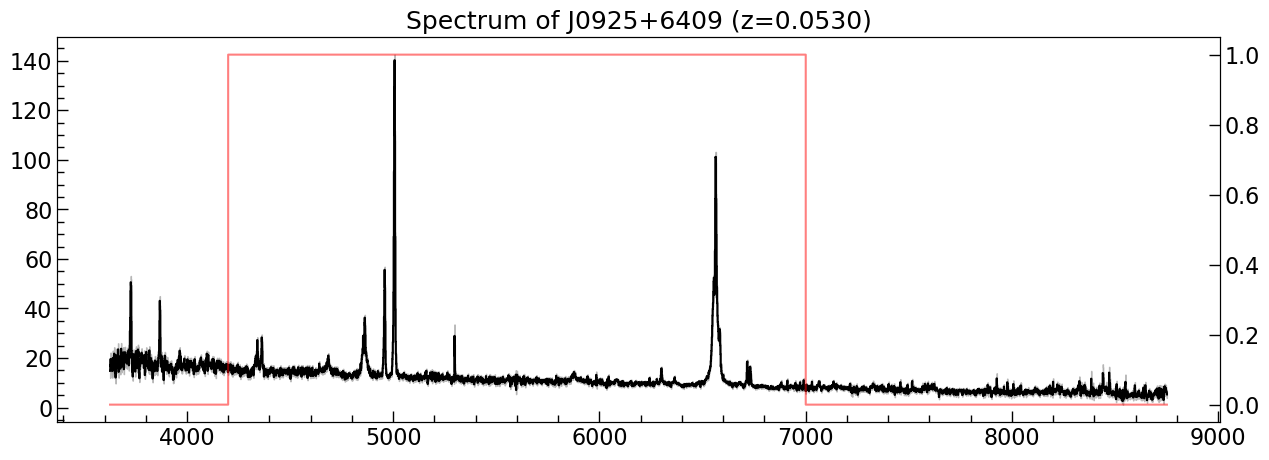

In [2]:
# get spectrum
tb = Table.read('../data_20251121/target_info.ipac', format='ipac')
loop = 0
targname = tb['Name'][loop]
Av = tb['Av'][loop]
zred = tb['zred'][loop]

# Read data
spec = np.loadtxt('results/J0925+6409_nostar.txt')
wave_use = spec[:, 0] / (1 + zred)
flux_use = spec[:, 1]
ferr_use = spec[:, 2]

wave_uni = np.linspace(wave_use.min(), wave_use.max(), len(wave_use))
flux_use, ferr_use = spectres.spectres(wave_uni, wave_use, flux_use, ferr_use)
fltr = ~np.isnan(flux_use) & ~np.isnan(ferr_use)
flux_use = flux_use[fltr]
ferr_use = ferr_use[fltr]
wave_use = wave_uni[fltr]


# Read the templates
temp_sii = np.loadtxt('results/J0925+6409_sii.txt')
velc_temp = temp_sii[:, 0]
flux_temp = temp_sii[:, 1]


# include the H-alpha, H-beta, and H-gamma line regions
weight_lines = np.zeros_like(wave_use)
#line_windows = [(4200, 4500), (4750, 5100), (6400, 6800)]
line_windows = [(4200, 5400), (5400, 6100), (6100, 7000)]
for window in line_windows:
    weight_lines[(wave_use > window[0]) & (wave_use < window[1])] = 1

fig, ax = plt.subplots(figsize=(15, 5))
ax.step(wave_use, flux_use, color='k', where='mid', label='Flux')
ax.fill_between(wave_use, flux_use - ferr_use, flux_use + ferr_use, color='gray', alpha=0.5, step='mid', label='Error')
ax.minorticks_on()

#ax.axvline(6363.776, color='C3', ls='--', alpha=0.7)
#ax.axvline(6300.304, color='C3', ls='--', alpha=0.7)
#ax.set_xlim([6100, 7000])
#ax.set_ylim([0, 38])

axr = ax.twinx()
axr.step(wave_use, weight_lines, color='r', where='mid', alpha=0.5, label='Line Regions')
ax.set_title(f'Spectrum of {targname} (z={zred:.4f})', fontsize=18)
plt.show()

## Fit the lines
* The [S II] is strong. Use it to be the narrow line template.
    * Need two components for the [S II]

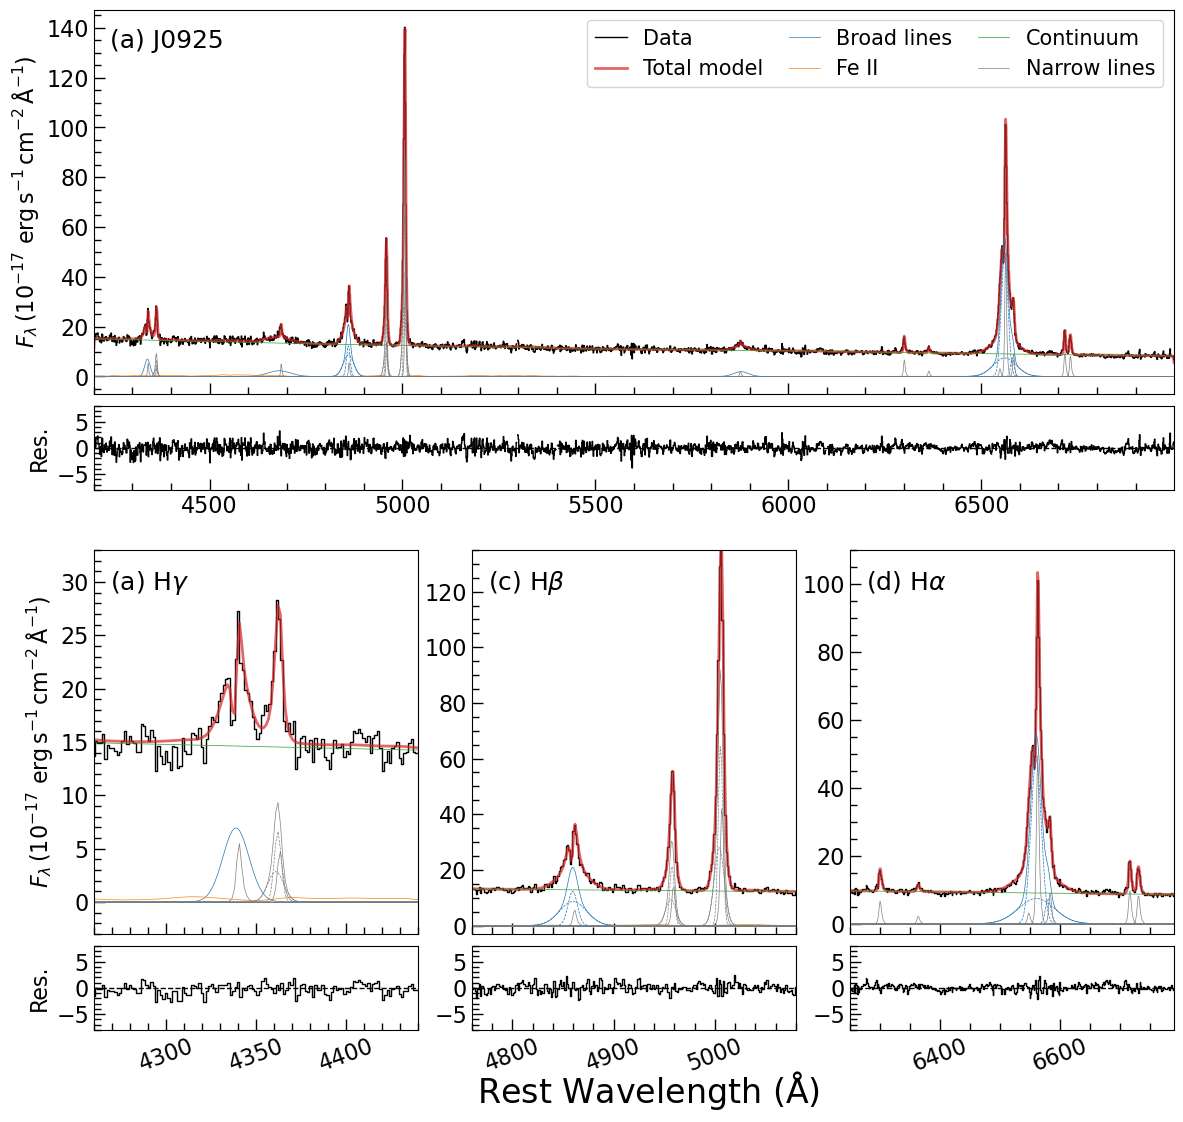

<Line_MultiGauss(amp_c=12.32286266, dv_c=-103.40726055, sigma_c=286.11098173, wavec=4861.333, amp_w0=0.70167145, dv_w0=22.75588603, sigma_w0=819.8147871, name='Broad H$\\beta$')>
<Line_MultiGauss(amp_c=6.94487932, dv_c=-103.40726055, sigma_c=500.35181726, wavec=4340.471, name='Broad H$\\gamma$')>
<WindowedPowerLaw1D(amplitude=12.13268701, x_0=5100., alpha=1.14972729, x_min=4200., x_max=5400., name='Cont Hb')>
<Line_Absorption(logtau0=1.14691047, dv=-161.00040907, sigma=41.40471513, Cf=0.40490026, wavec=4861.333, name='Abs. H$\\beta$')>
<Line_Absorption(logtau0=0.67407404, dv=-161.00040907, sigma=41.40471513, Cf=0.40490026, wavec=4340.471, name='Abs. H$\\gamma$')>
<Line_MultiGauss(amp_c=2.28007506, dv_c=-341.30527691, sigma_c=1871.77694189, wavec=4685.71, name='Broad He II')>
<IronTemplate(amplitude=0.79376601, stddev=623.59774503, z=0.003, name='Fe II')>
<Line_template(amplitude=5.74799109, dv=11.05398887, wavec=4861.333, name='nHbeta')>
<Line_template(amplitude=5.30406071, dv=11.05398

In [3]:
#################################################################################
# Fit Halpha + Hbeta + Hgamma
weight_lines = np.zeros_like(wave_use)
xlim = [wave_use.max(), wave_use.min()]
for window in line_windows:
    weight_lines[(wave_use > window[0]) & (wave_use < window[1])] = 1
    xlim[0] = min(xlim[0], window[0])
    xlim[1] = max(xlim[1], window[1])
weight_lines[(wave_use > 5398) & (wave_use < 5403)] = 0
weight_lines[(wave_use > 6097) & (wave_use < 6103)] = 0
#weight_lines[(wave_use > 4600) & (wave_use < 4750)] = 0  # Mask the He II 4686 region

for w0, w1 in tu.spec_masks['J0925']:
    weight_lines[(wave_use > w0) & (wave_use < w1)] = 0  # Mask some back pixels


cont_ha = galspec.WindowedPowerLaw1D(amplitude=9.06011706, x_0=6550., alpha=1.46334453, 
                                   x_min=line_windows[2][0], x_max=line_windows[2][1], name=f"Cont Ha")

bha = galspec.Line_MultiGauss(n_components=3, amp_c=48.38382151, dv_c=-103.35674916, sigma_c=395.37453303, 
                            amp_w0=0.15400504, dv_w0=22.86142189, sigma_w0=1358.83622657, 
                            amp_w1=0.15173354, dv_w1=922.10177208, sigma_w1=208.08109136,
                            wavec=wave_dict['Halpha'], name=label_bHa)
nha = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=49.66433997, dv=10.95670192, 
                          wavec=wave_dict['Halpha'], name='nHalpha')
nn2 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=9.39527829, dv=10.95670192, 
                          wavec=wave_dict['NII_6583'], name='NII_6583') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=3.1740805, dv=10.95670192, 
                         wavec=wave_dict['NII_6548'], name='NII_6548')
ns2 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=9.82496688, dv=10.95670192, 
                          wavec=wave_dict['SII_6716'], name='SII_6716') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=8.41515226, dv=10.95670192, 
                         wavec=wave_dict['SII_6731'], name='SII_6731')
no1 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=6.64348337, dv=10.95670192,
                          wavec=wave_dict['OI_6300'], name='OI_6300') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=2.21449446, dv=10.95670192,
                          wavec=wave_dict['OI_6364'], name='OI_6364')

aha = galspec.Line_Absorption(logtau0=2.0, dv=-160.9757517, sigma=41.41930428, Cf=0.405488, 
                            wavec=wave_dict['Halpha'], name=label_aHa)
aha.sigma.bounds = (5, 300)

b_lines = (bha + cont_ha) * aha
b_lines = galspec.convolve_lsf(b_lines, wavec=bha.wavec, resolving_power=resolving_power)
n_lines = nha + nn2 + ns2 + no1
m_fit_ha = b_lines + n_lines
m_fit_ha['NII_6548'].amplitude.tied = galspec.tie_template_amplitude('NII_6583', ratio=2.96)
m_fit_ha['OI_6364'].amplitude.tied = galspec.tie_template_amplitude('OI_6300', ratio=3.0)

for ln in ['NII_6583', 'NII_6548', 'SII_6716', 'SII_6731', 'OI_6300', 'OI_6364']:  #
    m_fit_ha[ln].dv.tied = galspec.tie_template_dv('nHalpha')

#################################################################################
# He I 5876
cont_he1 = galspec.WindowedPowerLaw1D(amplitude=15.0, x_0=5750., alpha=1.0, 
                                   x_min=line_windows[1][0], x_max=line_windows[1][1], name=f"Cont HeI")
bhe1 = galspec.Line_MultiGauss(n_components=1, amp_c=5.0, dv_c=-100., sigma_c=300., 
                             wavec=wave_dict['HeI_5876'], name=label_bHeI)
nhe1 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=5.0, dv=10.95670192, 
                           wavec=wave_dict['HeI_5876'], name='nHeI_5876')
m_fit_he1 = cont_he1 + bhe1 + nhe1


#################################################################################
# Hbeta
cont = galspec.WindowedPowerLaw1D(amplitude=12.12902055, x_0=5100., alpha=1.14471104, 
                                x_min=line_windows[0][0], x_max=line_windows[0][1], name=f'Cont Hb')
iron = galspec.IronTemplate(amplitude=0.83023727, stddev=662.5726041, z=0.003, name='Fe II')  #, fixed=dict(amplitude=True, z=True, stddev=True)

bhb = galspec.Line_MultiGauss(n_components=2, amp_c=12.34299175, dv_c=-103.35674916, sigma_c=285.96642984, 
                            amp_w0=0.70044714, dv_w0=22.86142189, sigma_w0=820.62286562, 
                            wavec=wave_dict['Hbeta'], name=label_bHb)
bhb.amp_w0.bounds = (0, 2)
nhb = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=5.74444931, dv=10.95670192, 
                          wavec=wave_dict['Hbeta'], name='nHbeta')
no3 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=43.8526928, dv=10.95670192, 
                          wavec=wave_dict['OIII_5007'], name='OIII_5007') +\
      galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=14.71566873, dv=10.95670192, 
                         wavec=wave_dict['OIII_4959'], name='OIII_4959')
no3_w = galspec.Line_MultiGauss(n_components=2, amp_c=65.28738878, dv_c=-69.75608655, sigma_c=134.42802579, 
                              amp_w0=0.43048997, dv_w0=-76.64533816, sigma_w0=295.91540955,
                              wavec=wave_dict['OIII_5007'], name='OIII_5007_w') +\
        galspec.Line_MultiGauss(n_components=2, amp_c=21.90851973, dv_c=-69.75608655, sigma_c=134.42802579, 
                              amp_w0=0.43048997, dv_w0=-76.64533816, sigma_w0=295.91540955,
                              wavec=wave_dict['OIII_4959'], name='OIII_4959_w')
ahb = galspec.Line_Absorption(logtau0=1.14691047, dv=-160.9757517, sigma=41.41930428, Cf=0.405488, wavec=wave_dict['Hbeta'], name=label_aHb)
ahb.sigma.bounds = (5, 300)

# He II 4686
nhe2 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=5.30887026, dv=10.95670192, 
                           wavec=wave_dict['HeII_4686'], name='nHeII_4686')
bhe2 = galspec.Line_MultiGauss(n_components=1, amp_c=2.27815954, dv_c=-332.02455588, sigma_c=1869.43745362, 
                             wavec=wave_dict['HeII_4686'], name=label_bHeII)

# Hgamma
bhg = galspec.Line_MultiGauss(n_components=1, amp_c=6.95065484, dv_c=-103.35674916, sigma_c=500.19743689, 
                            wavec=wave_dict['Hgamma'], name=label_bHg)
nhg = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=5.55729106, dv=10.95670192, 
                          wavec=wave_dict['Hgamma'], name='nHgamma')
no3_4360 = galspec.Line_template(template_velc=velc_temp, template_flux=flux_temp, amplitude=4.86012388, dv=10.95670192, 
                               wavec=wave_dict['OIII_4363'], name='OIII_4363')
no3_4360_w = galspec.Line_MultiGauss(n_components=2, amp_c=6.61152781, dv_c=-69.75608655, sigma_c=134.42802579, 
                                   amp_w0=0.43048997, dv_w0=-76.64533816, sigma_w0=295.91540955,
                                   wavec=wave_dict['OIII_4363'], name='OIII_4363_w')
ahg = galspec.Line_Absorption(logtau0=0.67407404, dv=-160.9757517, sigma=41.41930428, Cf=0.405488, wavec=wave_dict['Hgamma'], name=label_aHg)
ahg.sigma.bounds = (5, 300)

b_lines = (bhb + bhg + cont) * ahb * ahg + bhe2
b_lines = galspec.convolve_lsf(b_lines, wavec=bhb.wavec, resolving_power=resolving_power)
m_init = b_lines + iron + nhb + nhe2 + no3 + no3_w + nhg + no3_4360 + no3_4360_w + m_fit_ha + m_fit_he1

for ln in ['nHbeta', 'OIII_5007', 'OIII_4959', 'nHgamma', 'OIII_4363', 'nHeII_4686', 'nHeI_5876']:
    m_init[ln].dv.tied = galspec.tie_template_dv('nHalpha')

m_init['OIII_4959'].amplitude.tied = galspec.tie_template_amplitude('OIII_5007', ratio=2.98)
m_init['OIII_4959_w'].amp_c.tied = galspec.tie_MultiGauss_amp_c('OIII_5007_w', ratio=2.98)
m_init['OIII_4959_w'].dv_c.tied = galspec.tie_MultiGauss_dv_c('OIII_5007_w')
m_init['OIII_4959_w'].sigma_c.tied = galspec.tie_MultiGauss_sigma_c('OIII_5007_w')
m_init['OIII_4959_w'].amp_w0.tied = galspec.tie_MultiGauss_amp_w0('OIII_5007_w')
m_init['OIII_4959_w'].dv_w0.tied = galspec.tie_MultiGauss_dv_w0('OIII_5007_w')
m_init['OIII_4959_w'].sigma_w0.tied = galspec.tie_MultiGauss_sigma_w0('OIII_5007_w')
m_init['OIII_4363_w'].dv_c.tied = galspec.tie_MultiGauss_dv_c('OIII_5007_w')
m_init['OIII_4363_w'].sigma_c.tied = galspec.tie_MultiGauss_sigma_c('OIII_5007_w')
m_init['OIII_4363_w'].amp_w0.tied = galspec.tie_MultiGauss_amp_w0('OIII_5007_w')
m_init['OIII_4363_w'].dv_w0.tied = galspec.tie_MultiGauss_dv_w0('OIII_5007_w')
m_init['OIII_4363_w'].sigma_w0.tied = galspec.tie_MultiGauss_sigma_w0('OIII_5007_w')

m_init[label_aHb].dv.tied = galspec.tie_Absorption_dv(label_aHa)
m_init[label_aHb].sigma.tied = galspec.tie_Absorption_sigma(label_aHa)
m_init[label_aHg].dv.tied = galspec.tie_Absorption_dv(label_aHa)
m_init[label_aHg].sigma.tied = galspec.tie_Absorption_sigma(label_aHa)
m_init[label_aHb].Cf.tied = galspec.tie_Absorption_Cf(label_aHa)
m_init[label_aHg].Cf.tied = galspec.tie_Absorption_Cf(label_aHa)
m_init[label_aHb].logtau0.tied = galspec.tie_Absorption_logtau0(label_aHa, ratio=7.13)
m_init[label_aHg].logtau0.tied = galspec.tie_Absorption_logtau0(label_aHa, ratio=21.18)
m_init[label_aHa].logtau0.bounds = (-2, 2)

m_init[label_bHb].dv_c.tied = galspec.tie_MultiGauss_dv_c(label_bHa)
m_init[label_bHb].dv_w0.tied = galspec.tie_MultiGauss_dv_w0(label_bHa)
m_init[label_bHg].dv_c.tied = galspec.tie_MultiGauss_dv_c(label_bHa)

fwhm_ha = galspec.line_emission_fwhm(m_init, [label_bHa], wave_use, wave_dict['Halpha'])
m_init['Fe II'].amplitude.bounds = (0, None)
m_init['Fe II'].stddev = fwhm_ha/2.3548
m_init['Fe II'].stddev.bounds = (fwhm_ha/2.3548/1.5, fwhm_ha/2.3548*1.5)
m_init['Fe II'].z.bounds = (-0.003, 0.003)

fitter = fitting.LevMarLSQFitter()
m_fit_hb = fitter(m_init, wave_use, flux_use, weights=weight_lines, maxiter=10000)

fig, axs = tu.plot_all_4p_J0925(wave_use, flux_use, m_fit_hb, weight=weight_lines)
#axs[0, 0].set_xlim(5380, 5420)
#plt.savefig('results/figs/J0925+6409_4p_levmar.pdf', bbox_inches='tight')
plt.show()

for m in m_fit_hb:
    print(m.__repr__())

Running MCMC with all parameters varying...
MCMC_Fit initialized with 53 free parameters.
[14.77637889 17.21837448 19.58980043 ...  6.46740161  6.04637741
  5.26446   ]
1745


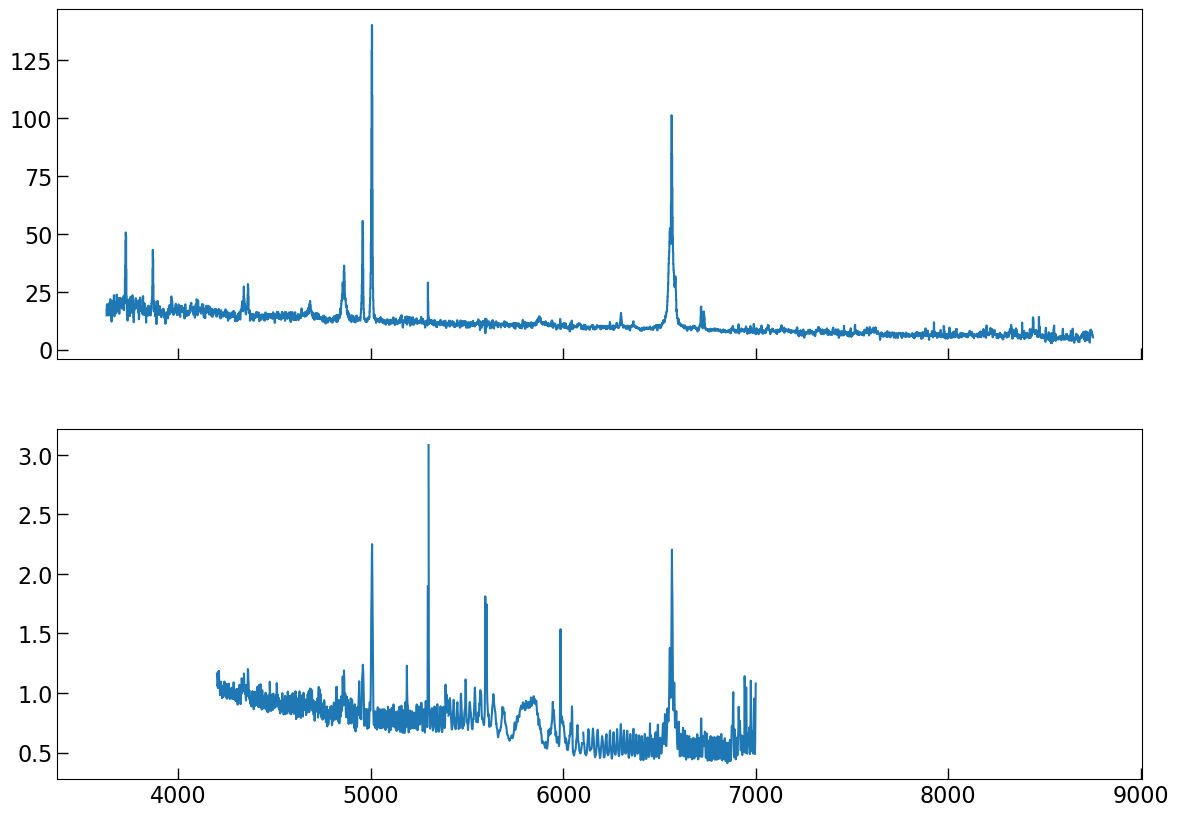

In [ ]:
##################################################################################
print('Running MCMC with all parameters varying...')
mcmc = tu.run_mcmc_all(m_init, wave_use, flux_use, ferr_use, weight_lines, 
                       nwalkers=200, nsteps=100, nburn=50, fit=False)
mcmc.fit()
#print(mcmc.flux_use)
#
#fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
#ax1.step(mcmc.wave_use, mcmc.flux_use)
#ax2.plot(mcmc.wave_use, mcmc.ferr)
#print(np.sum(~np.isfinite(mcmc.ferr)))
#plt.show()

### Run MCMC sampling

In [ ]:
mcmc1 = tu.run_mcmc_balmer(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, 
                           nwalkers=200, nsteps=15000, step_initial=5000, fit=True)
mcmc1.check_convergence()
mcmc1.save_samples('results/samples/J0925+6409_samples_balmer.npz')
galspec.save_mcmc(mcmc1, 'results/models/galspec-model-J0925+6409.pkl')

mcmc2 = tu.run_mcmc_others(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, 
                           nwalkers=200, nsteps=15000, step_initial=5000, fit=True)
mcmc2.check_convergence()
mcmc2.save_samples('results/samples/J0925+6409_samples_others.npz')

1568 points used in MCMC for broad lines.
MCMC_Fit initialized with 40 free parameters.


100%|██████████| 15000/15000 [5:56:10<00:00,  1.42s/it]     


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 40 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 300;
tau: [1114.08321744  914.3132181  1099.50969144 1018.42734995  818.97700599
  783.16204756  850.03766996  820.53671928  786.56666484  952.4614154
 1040.40712621  954.95349957  998.52802098 1087.11542654 1006.15506367
  989.24156229  811.91089106  862.51754459  918.97492939  901.93470306
  878.23552119  934.06394287  871.79037478  892.41851553  871.74017965
  823.29624691  906.29409876  886.54211276  806.02171552  768.58906607
 1041.63792761  837.30178177 1029.67502391  830.29676926  893.32996715
  837.45635718  890.61432977  832.80359826  813.48019641  811.46618361]
Chain is probably too short to reliably estimate tau.
MCMC_Fit initialized with 20 free parameters.


  0%|          | 0/5000 [00:00<?, ?it/s]/Users/shangguan/Softwares/miniforge3/envs/norm/lib/python3.13/site-packages/emcee/moves/red_blue.py:99: RuntimeWarning: invalid value encountered in scalar subtract
  lnpdiff = f + nlp - state.log_prob[j]
100%|██████████| 15000/15000 [2:28:30<00:00,  1.68it/s]     


AutocorrError: The chain is shorter than 50 times the integrated autocorrelation time for 20 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 300;
tau: [342.78531666 346.19319407 370.80497995 395.83348878 423.72413985
 488.17878505 508.51115821 488.30439103 428.79079278 485.9341166
 433.96681243 443.01617354 419.37919085 434.73578927 339.23412477
 338.38376626 342.97423649 371.99830062 328.27965406 354.27466822]
Chain is probably too short to reliably estimate tau.


### Load the MCMC fitting
* Save the best-fit model figure
* Save the decomposed absorption line figure

1568 points used in MCMC for broad lines.
MCMC_Fit initialized with 40 free parameters.
MCMC_Fit initialized with 20 free parameters.


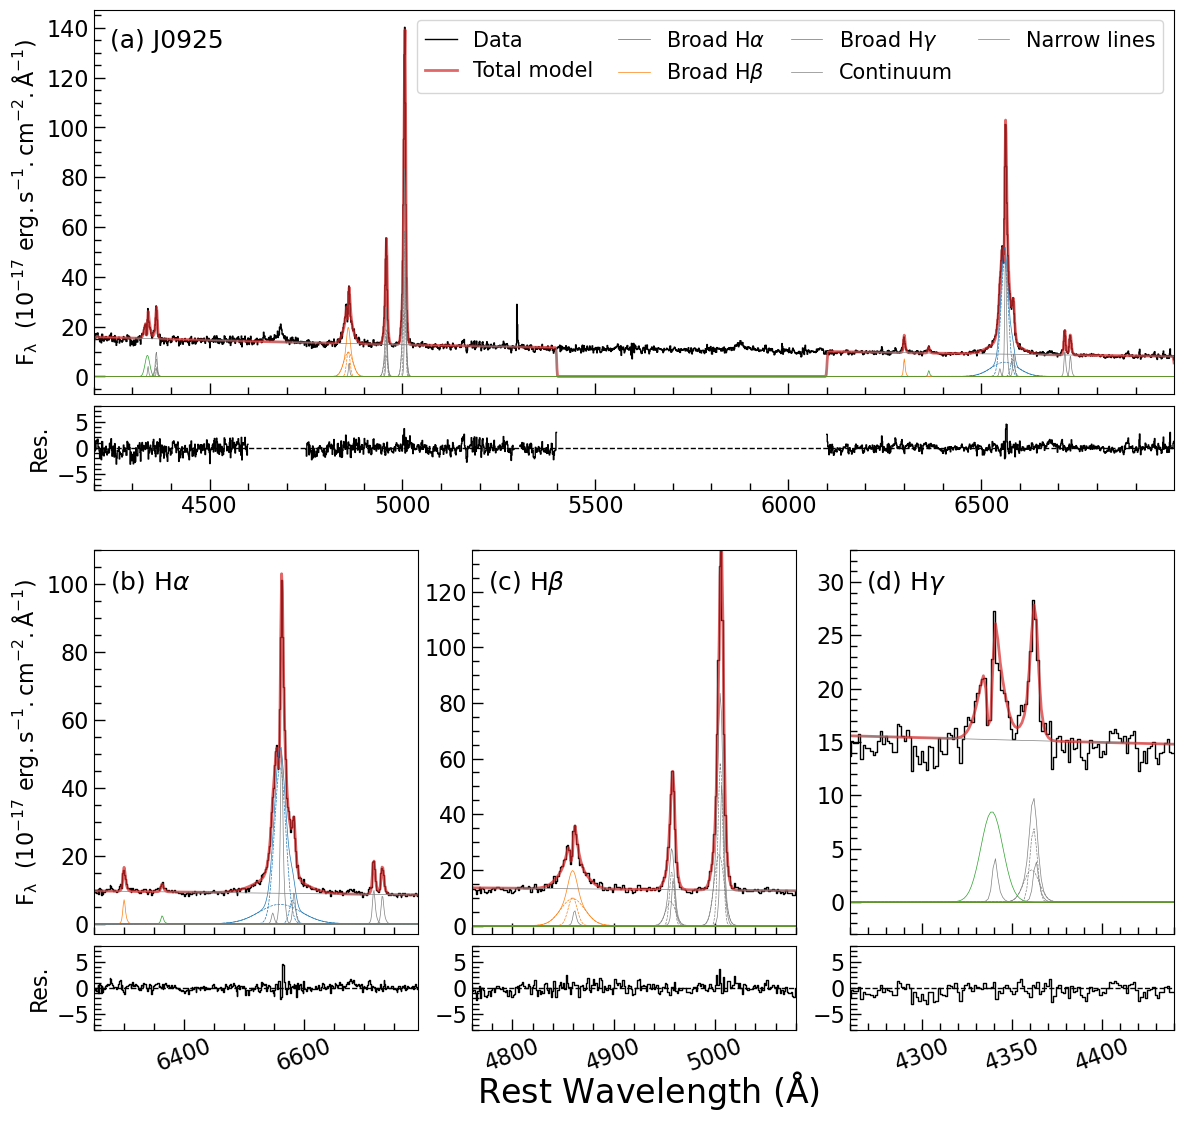

/Users/shangguan/Dropbox/Products/Latex/Absorption_selection/work/fitting_nb/temp_utils.py:388: RuntimeWarning: divide by zero encountered in divide
  wave, flux, m_fit, cont_models, abs_models, balmer_models)
/Users/shangguan/Dropbox/Products/Latex/Absorption_selection/work/fitting_nb/temp_utils.py:388: RuntimeWarning: overflow encountered in divide
  wave, flux, m_fit, cont_models, abs_models, balmer_models)


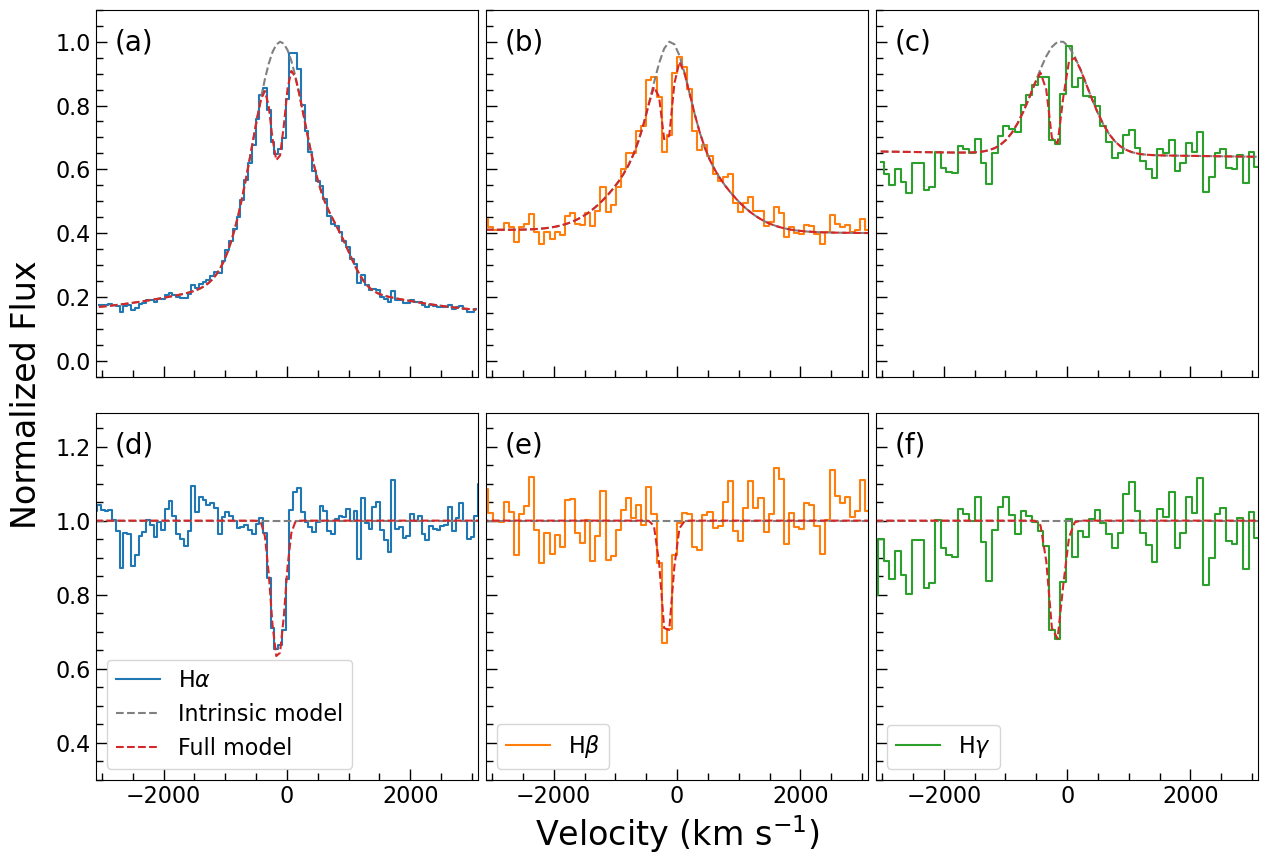

<Line_MultiGauss__GaussConv1D(amp_c=10.11128448, dv_c=-106.38659943, sigma_c=270.42118889, wavec=4861.333, amp_w0=0.95556096, dv_w0=3.91248951, sigma_w0=729.38298894, name='Broad H$\\beta$')>
<Line_MultiGauss__GaussConv1D(amp_c=8.4673758, dv_c=-106.38659943, sigma_c=420.33191932, wavec=4340.471, name='Broad H$\\gamma$')>
<WindowedPowerLaw1D(amplitude=12.43488616, x_0=5100., alpha=1.24876721, x_min=4200., x_max=5400., name='Cont Hb')>
<Line_Absorption(logtau0=3.247346, dv=-163.24362004, sigma=26.87235617, Cf=0.40938042, wavec=4861.333, name='Abs. H$\\beta$')>
<Line_Absorption(logtau0=2.77450958, dv=-163.24362004, sigma=26.87235617, Cf=0.40938042, wavec=4340.471, name='Abs. H$\\gamma$')>
<IronTemplate(amplitude=0., stddev=1000., z=0., name='Fe II')>
<Line_template(amplitude=5.51785612, dv=5.14959524, wavec=4861.333, name='nHbeta')>
<Line_template(amplitude=52.10524364, dv=5.14959524, wavec=5006.843, name='OIII_5007')>
<Line_template(amplitude=17.48498109, dv=5.14959524, wavec=4958.911, n

In [ ]:
mcmc1 = tu.run_mcmc_balmer(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, fit=False)
mcmc2 = tu.run_mcmc_others(m_fit_hb, wave_use, flux_use, ferr_use, line_windows, fit=False)

mcmc1.load_samples('results/samples/J0925+6409_samples_balmer.npz')
mcmc2.load_samples('results/samples/J0925+6409_samples_others.npz')

m_fit1, _, _ = mcmc1.get_best_fit()
m_fit2, _, _ = mcmc2.get_best_fit()

tu.plot_all_4p_J0925(wave_use, flux_use, m_fit1, weight=weight_lines)
plt.savefig('figs/J0925+6409_4p.pdf', bbox_inches='tight')
plt.show()

cont_models = ['Cont Ha', 'Cont Hb']
balmer_em_models = [label_bHa, label_bHb, label_bHg]
balmer_abs_models = [[label_aHa], [label_aHb], [label_aHg]]
line_names = ['Halpha', 'Hbeta', 'Hgamma']

tu.plot_decomposed_balmer(wave_use, flux_use, m_fit1, cont_models, balmer_abs_models, 
                          balmer_em_models, line_names, xlim=[-3100, 3100])
plt.savefig('figs/J0925+6409_balmer.pdf', bbox_inches='tight')
plt.show()

#tu.plot_all_4p_J0925(wave_use, flux_use, m_fit2, weight=weight_lines)
#plt.show()

for m in m_fit1:
    print(m.__repr__())

In [ ]:
res = tu.measure_phys(mcmc1, mcmc2, wave_use, zred, nsamples=5000, cont_names=['Cont Ha', 'Cont Hb'])
tb = tu.table_phys(res)

logtau0 = mcmc1.get_param_samples(label_aHa, 'logtau0')
logtau0_low = np.percentile(logtau0, 0.3)
fltr = tb['Parameter'] == f'logtau0_abs_Ha'
tb['Value'][fltr] = logtau0_low
tb['Error'][fltr] = np.nan

fltr = tb['Parameter'] == f'logtau0_abs_Hb'
tb['Value'][fltr] = logtau0_low - np.log10(7.13)
tb['Error'][fltr] = np.nan

fltr = tb['Parameter'] == f'logtau0_abs_Hg'
tb['Value'][fltr] = logtau0_low - np.log10(21.18)
tb['Error'][fltr] = np.nan

tb.write('results/J0925+6409_phys_table.ipac', format='ipac', overwrite=True)


tb.show_in_notebook()

         interactive tables it is recommended to use dedicated tools like:
         - https://github.com/bloomberg/ipydatagrid
         - https://docs.bokeh.org/en/latest/docs/user_guide/interaction/widgets.html#datatable
         - https://dash.plotly.com/datatable [warnings]


idx,Parameter,Value,Error
0,Flux_broad_Ha,1662.5747105102373,24.603026292339734
1,Flux_narrow_Ha,328.3219458711494,11.727512093539337
2,FWHM_broad_Ha,1101.3359774994387,47.79416541172194
3,EW_abs_Ha,2.138184154941181,0.12805636493448838
4,Cf_abs_Ha,0.3995644381882305,0.02174845709870596
5,logtau0_abs_Ha,1.6463694527425432,nan
6,dv_abs_Ha,-157.6075908055617,5.573734907570064
7,sigma_abs_Ha,29.27383408594486,4.697570690227171
8,EW_em_Ha,185.5103594901158,2.886690795630004
9,Flux_broad_Hb,393.0351691304153,12.246004109991187


In [ ]:
mcmc1.plot_corner(thin=100)
plt.show()

<Line_MultiGauss(amp_c=13.74887486, dv_c=-117.2240081, sigma_c=398.26750779, wavec=4861.333, amp_w0=0.33487254, dv_w0=39.33447322, sigma_w0=1068.56409819, name='Broad H$\\beta$')>
<Line_MultiGauss(amp_c=5.46844552, dv_c=-117.2240081, sigma_c=505.44722172, wavec=4340.471, name='Broad H$\\gamma$')>
<WindowedPowerLaw1D(amplitude=12.3560113, x_0=5100., alpha=1.14622816, x_min=4200., x_max=5400., name='Cont Hb')>
<Line_Absorption(tau_0=5.87137684, dv=-141.86140147, sigma=49.71824844, Cf=0.37824965, wavec=4861.333, name='Abs. H$\\beta$')>
<Line_Absorption(tau_0=1.97653054, dv=-141.86140147, sigma=49.71824844, Cf=0.37824965, wavec=4340.471, name='Abs. H$\\gamma$')>
<IronTemplate(amplitude=0., stddev=1000., z=0., name='Fe II')>
<Line_template(amplitude=8.67759413, dv=5.41512696, wavec=4861.333, name='nHbeta')>
<Line_template(amplitude=71.18733563, dv=5.41512696, wavec=5006.843, name='OIII_5007')>
<Line_template(amplitude=23.88836766, dv=5.41512696, wavec=4958.911, name='OIII_4959')>
<Line_Mult